В этом блокноте Jupyter основное внимание уделяется прогнозированию того, подпишется ли клиент на срочный депозит, что является проблемой бинарной классификации. Ключевые шаги включают:
1. Загрузка и изучение данных.
2. Очистка и предварительная обработка данных, включая обработку пропущенных значений и кодирование категориальных признаков.
3. Разделение данных на обучающие, валидационные и тестовые наборы.
4. Масштабирование данных.
5. Устранение дисбаланса классов.
6. Выбор и анализ признаков.
7. Оценка модели, включая следующие ключевые показатели:
   
   а) Accuracy: 0.9738

   б) Recall: 1.0000

   в) F1 Score: 0.9744

# 0) Загрузим все необходимые библиотеки

In [15]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from imblearn.over_sampling import RandomOverSampler
from scipy.stats import ttest_ind
from yellowbrick.classifier import DiscriminationThreshold, PrecisionRecallCurve

## 1) Загрузим данные

In [16]:
data = pd.read_csv('bank.csv', sep=';')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [17]:
#Изменим имя целевой переменной для удобства
data.rename(columns={'y': 'term_deposit'}, inplace=True)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           4521 non-null   int64 
 1   job           4521 non-null   object
 2   marital       4521 non-null   object
 3   education     4521 non-null   object
 4   default       4521 non-null   object
 5   balance       4521 non-null   int64 
 6   housing       4521 non-null   object
 7   loan          4521 non-null   object
 8   contact       4521 non-null   object
 9   day           4521 non-null   int64 
 10  month         4521 non-null   object
 11  duration      4521 non-null   int64 
 12  campaign      4521 non-null   int64 
 13  pdays         4521 non-null   int64 
 14  previous      4521 non-null   int64 
 15  poutcome      4521 non-null   object
 16  term_deposit  4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [19]:
# Конвертируем целевую переменную в числовой бинарный формат
data['term_deposit'] = data['term_deposit'].apply(lambda x: 1 if x == 'yes' else 0)

In [20]:
# Разделим категариальные и числовые фичи
categorical_features = data.select_dtypes(include=['object']).columns.tolist()
numerical_features = data.select_dtypes(include=['int', 'float']).columns.tolist()

# 2) Очистка данных

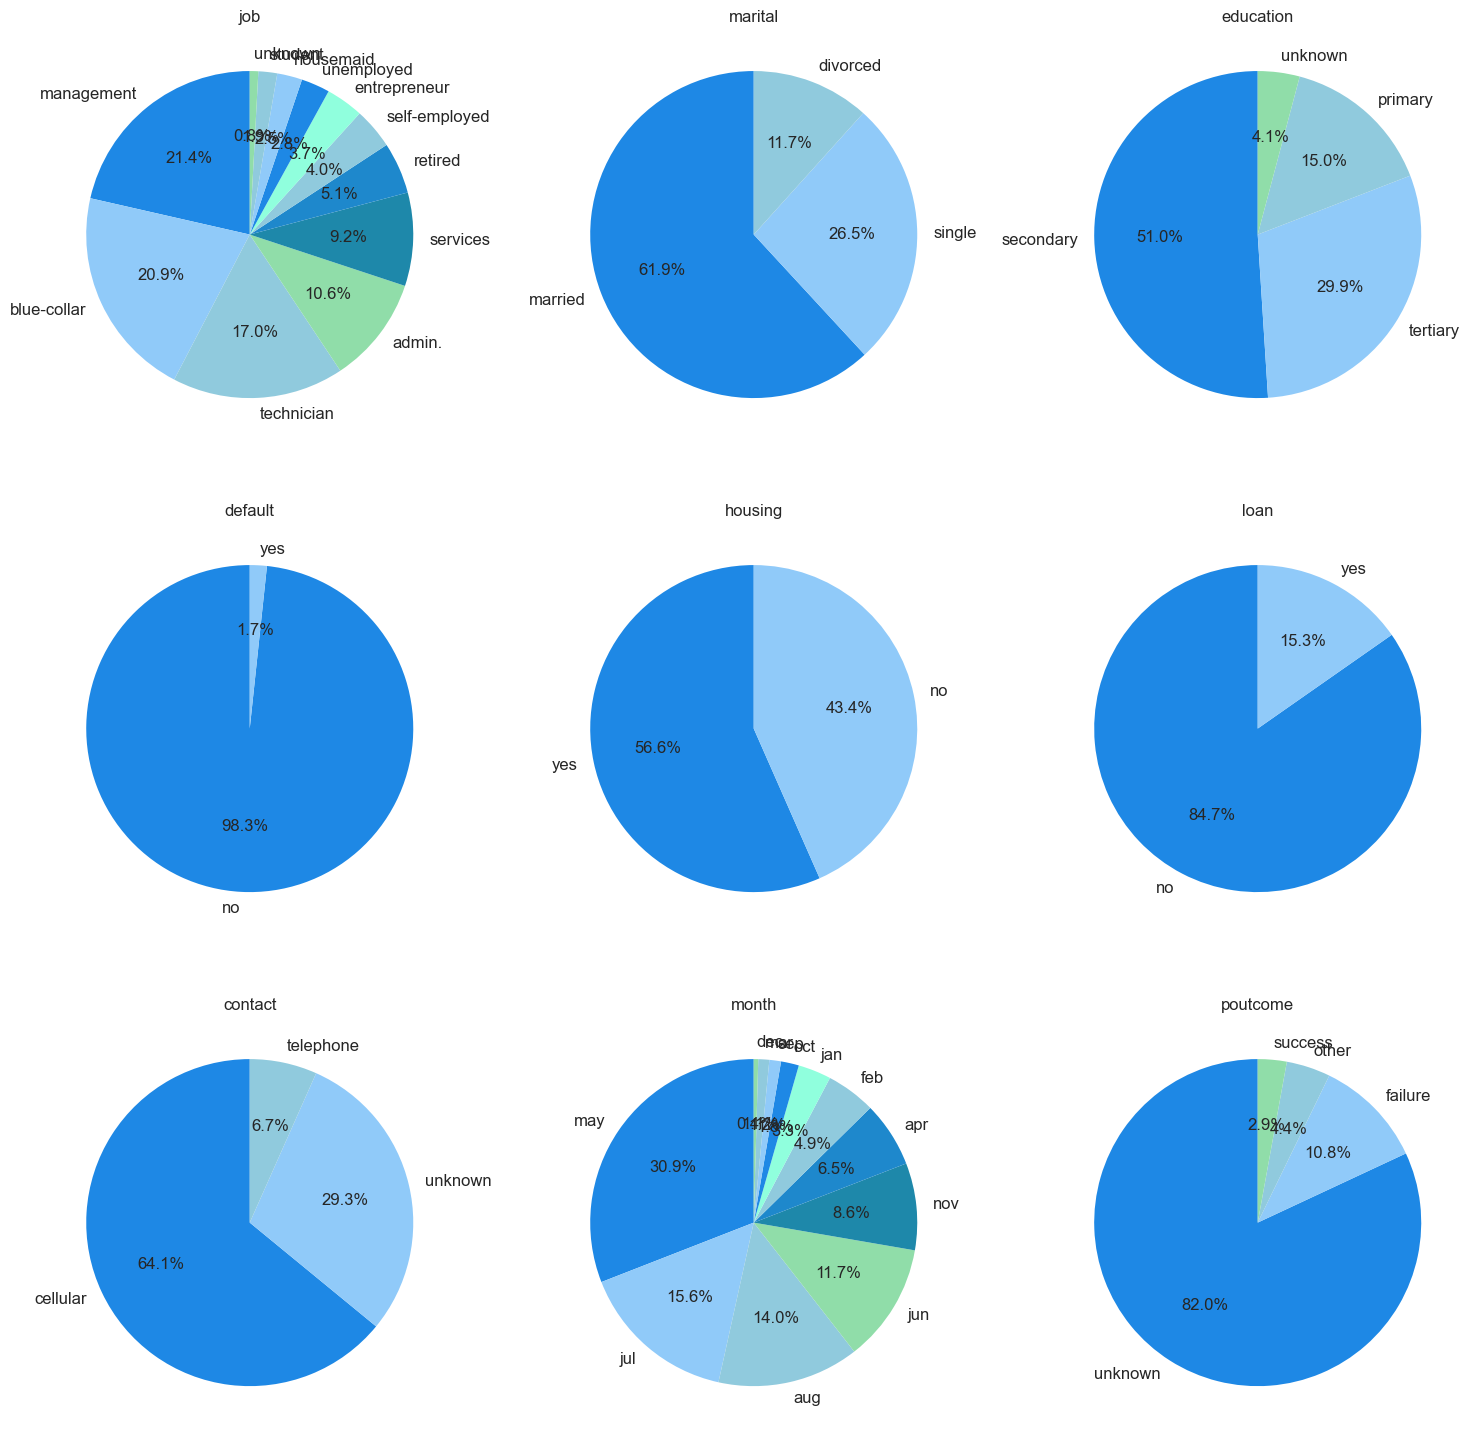

In [21]:
colors = ['#1E88E5', '#90CAF9', '#90CADD', '#90DDA9', '#1E88AA', '#1E88CC', '#90CADD', '#90FFDD']

# Посмотрим на распределение категариальных фичей используя круговые диаграммы и проверим наличие 'unknown' значений.
cols = 3
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    data[feature].value_counts().plot(
        kind='pie', 
        autopct='%1.1f%%', 
        colors=colors,
        startangle=90,
        textprops={'fontsize': 12},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\Grengald\AppData\Local\Temp\ipykernel_15100\2469905677.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


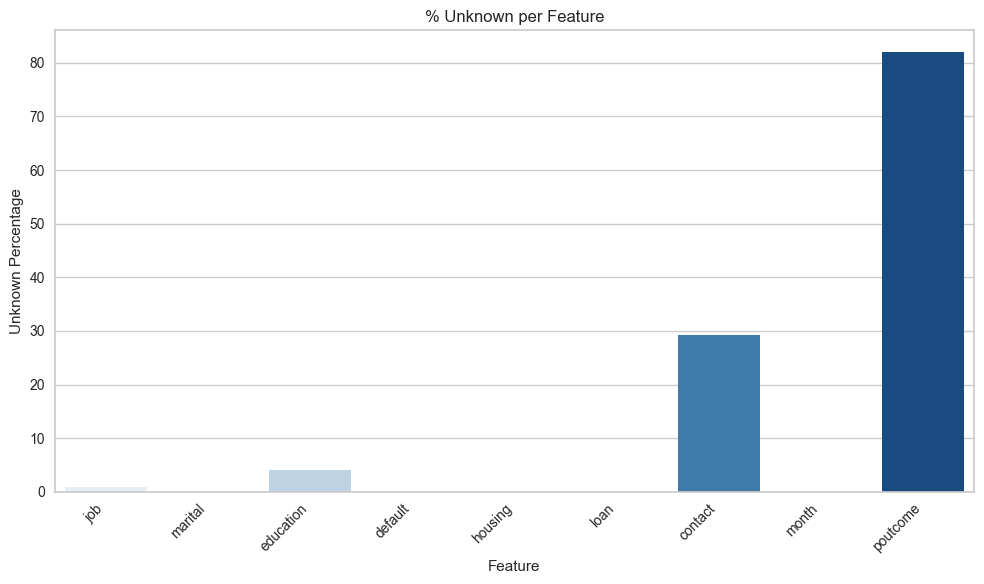

In [22]:
unknown_percentages = {}

# Проитерируемся по каждому фичу
for feature in categorical_features:
    unknown_count = data[feature].value_counts().get('unknown', 0)
    total_count = len(data[feature])
    percentage = (unknown_count / total_count) * 100
    unknown_percentages[feature] = percentage

# Конвертируем словарь в DataFrame для удобства
unknown_df = pd.DataFrame(list(unknown_percentages.items()), columns=['Feature', 'Unknown Percentage'])

plt.figure(figsize=(10, 6))
sns.barplot(
    data=unknown_df,
    x='Feature',
    y='Unknown Percentage',
    palette='Blues'
)
plt.title('% Unknown per Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [23]:
# Удалим фичи 'contact' и 'poutcome', поскольку в них высокий процент 'unknown' значений.
data.drop(columns=['contact', 'poutcome'], inplace=True)

In [24]:
# Отфильтруем строки, в которых столбцы 'education' или 'job' равны 'unknown'
data = data[data['education'] != 'unknown']
data = data[data['job'] != 'unknown']

In [25]:
# Переведём категориальные фичи в числовой формат
label_encoders = {}
categorical_features = data.select_dtypes(include=['object']).columns.tolist()

data_encoded = data.copy()

for col in categorical_features:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data[col])
    label_encoders[col] = le  
    
data_encoded.head()

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,term_deposit
0,30,10,1,0,0,1787,0,0,19,10,79,1,-1,0,0
1,33,7,1,1,0,4789,1,1,11,8,220,1,339,4,0
2,35,4,2,2,0,1350,1,0,16,0,185,1,330,1,0
3,30,4,1,2,0,1476,1,1,3,6,199,4,-1,0,0
4,59,1,1,1,0,0,1,0,5,8,226,1,-1,0,0


# 3) Проведём развёрнутый анализ данных

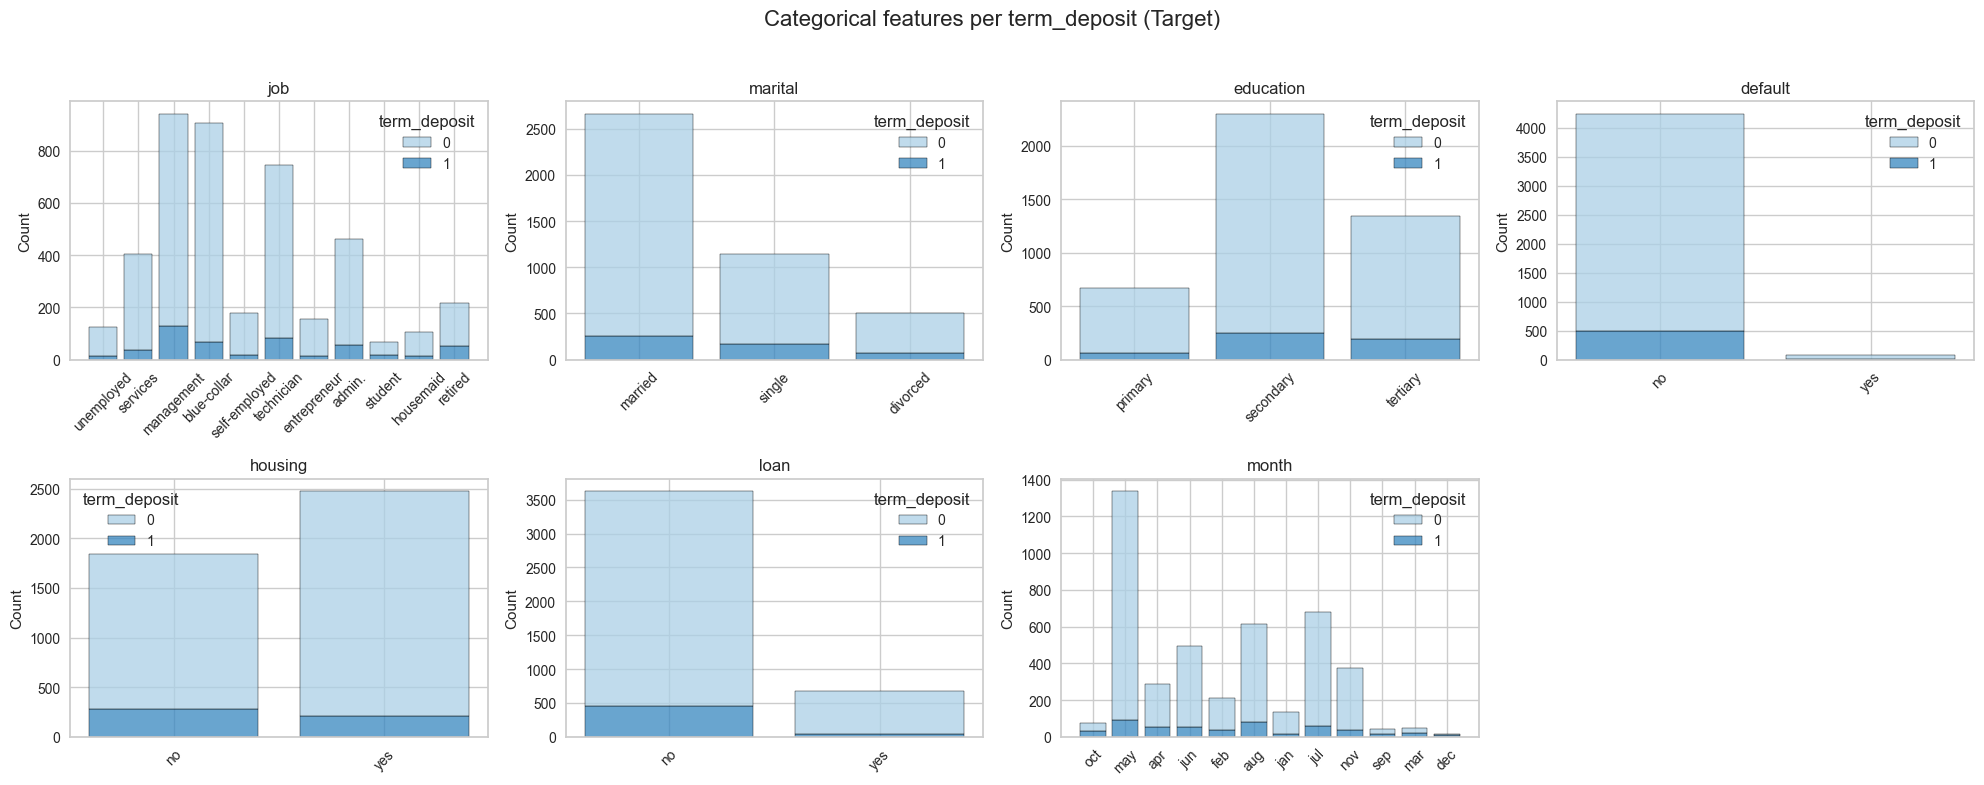

In [26]:
# Посмотрим на рапределение целевой переменной относительно категориальных фичей
cols = 4
rows = -(-len(categorical_features) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.histplot(
        data=data,
        x=feature,
        hue='term_deposit',
        multiple='stack',
        palette='Blues',
        ax=axes[i],
        shrink=0.8
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Categorical features per term_deposit (Target)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Deja espacio para el título
plt.show()

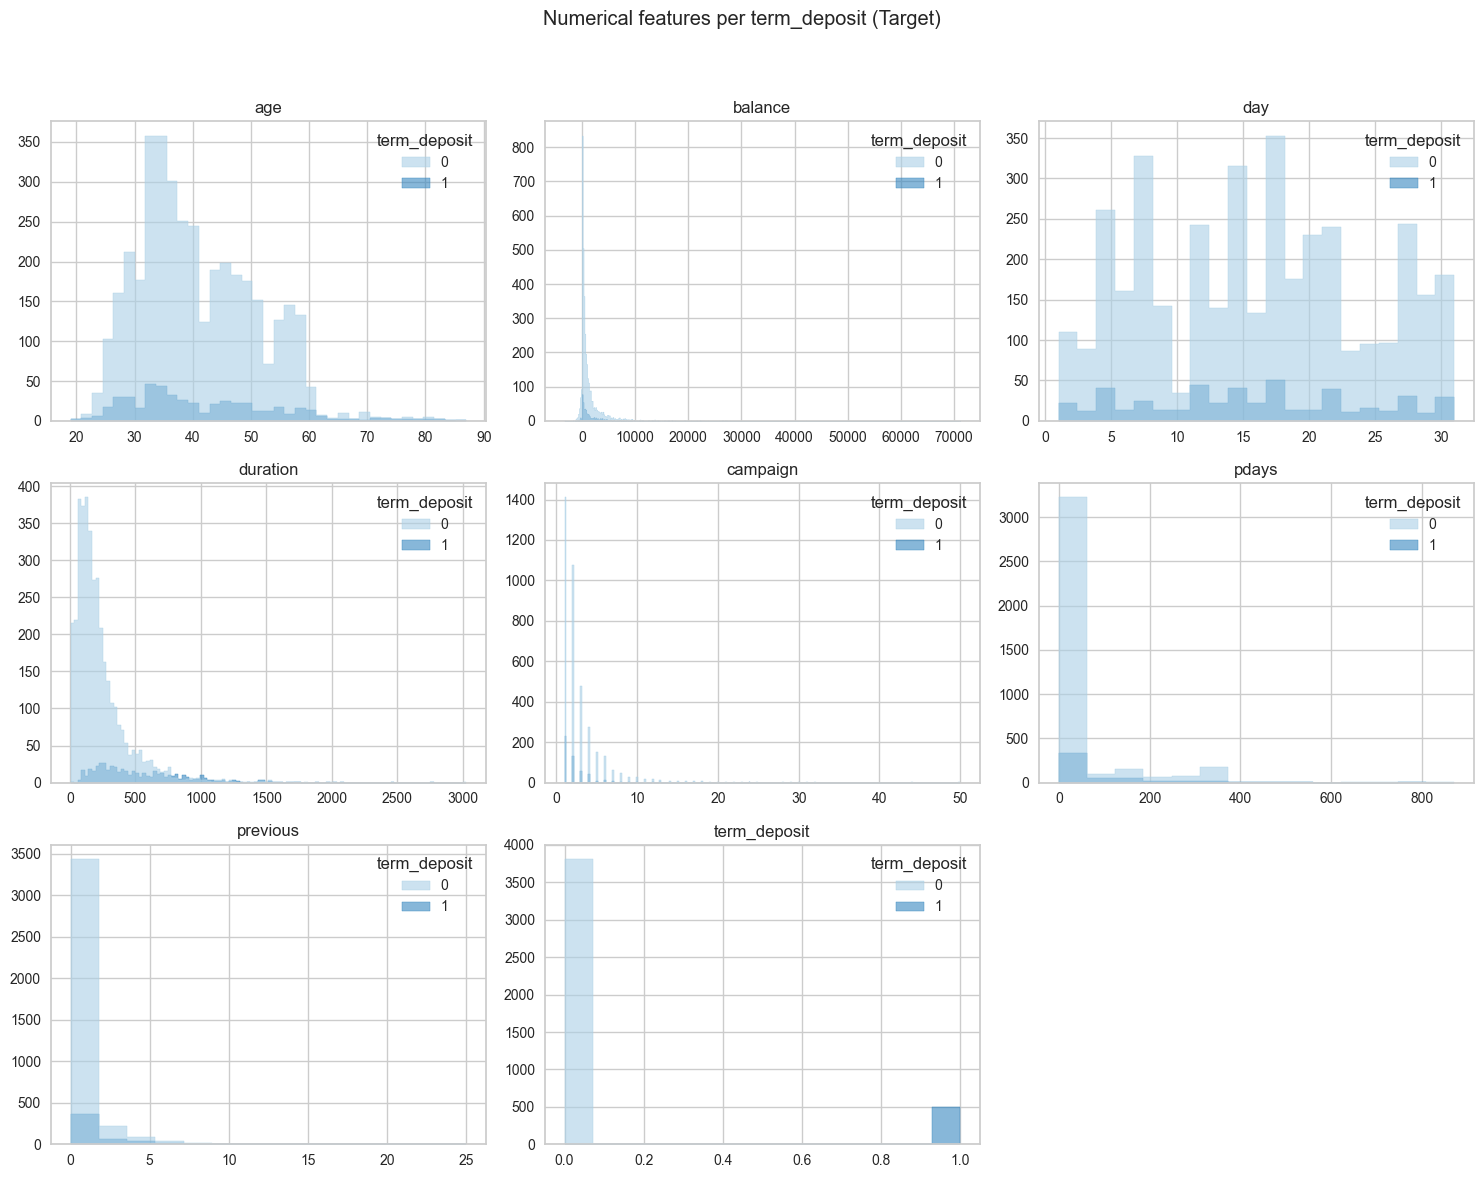

In [27]:
# Посмотрим на рапределение целевой переменной относительно числовых фичей
cols = 3
rows = -(-len(numerical_features) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=data,
        x=feature,
        hue='term_deposit',
        palette='Blues',
        element='step',
        stat='count',
        common_norm=False,
        alpha=0.6,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Numerical features per term_deposit (Target)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

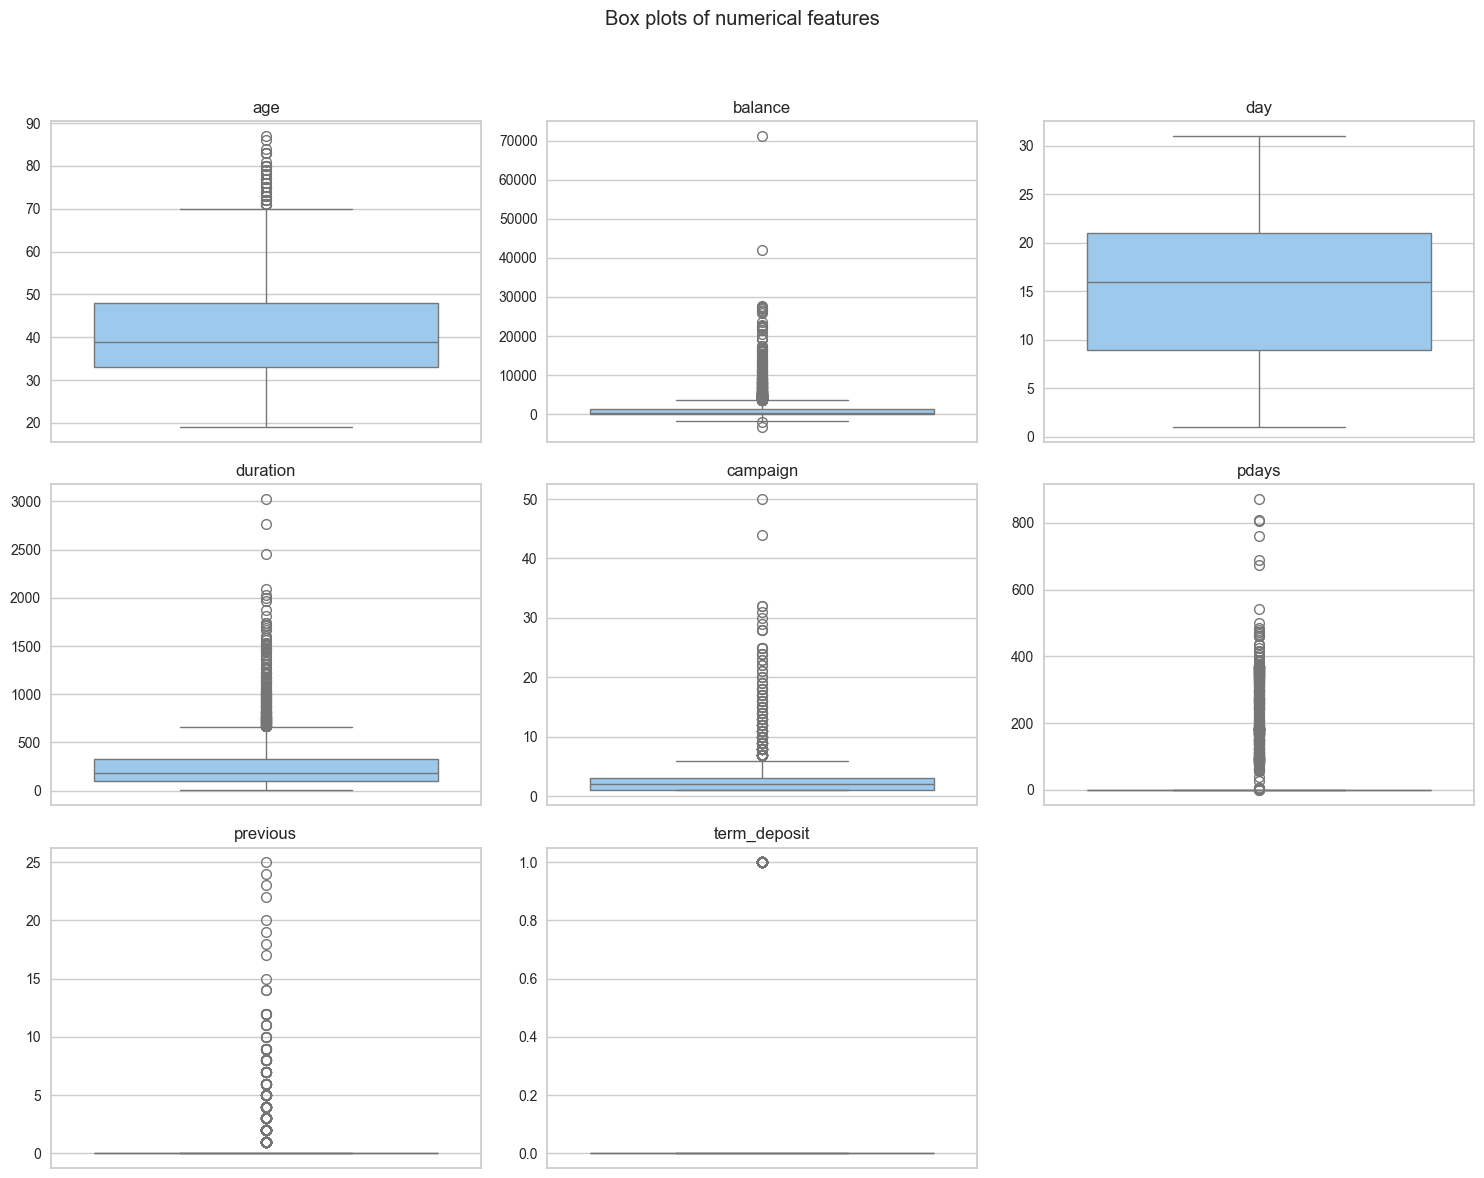

In [28]:
# Построим боксплоты для числовых фичей
cols = 3
rows = -(-len(numerical_features) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=data_encoded,
        y=feature,
        color=colors[1],
        ax=axes[i]
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Box plots of numerical features')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [29]:
# Проведём t-тесты для числовых фичей, чтобы сравнить средние значения между двумя группами, определенными целевой переменной, 
#а затем идентифицирует признаки со статистически значимыми различиями.
class_yes = data_encoded[data_encoded['term_deposit'] == 1]
class_no = data_encoded[data_encoded['term_deposit'] == 0]

numeric_features = data_encoded.columns[:-1]

t_test_results = {}

for feature in numeric_features:
    t_stat, p_value = ttest_ind(class_yes[feature], class_no[feature], equal_var=False)
    t_test_results[feature] = p_value

t_test_df = pd.DataFrame(list(t_test_results.items()), columns=['Feature', 'P-Value'])
t_test_df['Significant'] = t_test_df['P-Value'] < 0.05 

t_test_df = t_test_df.sort_values(by='P-Value')

t_test_df

,Feature,P-Value,Significant
10,duration,2.911959e-59,True
6,housing,1.104312e-11,True
13,previous,2.283511e-10,True
7,loan,2.353830e-09,True
11,campaign,3.853991e-09,True
12,pdays,3.384614e-08,True
3,education,1.863111e-04,True
9,month,6.010510e-03,True
0,age,3.512646e-02,True
1,job,6.557274e-02,False


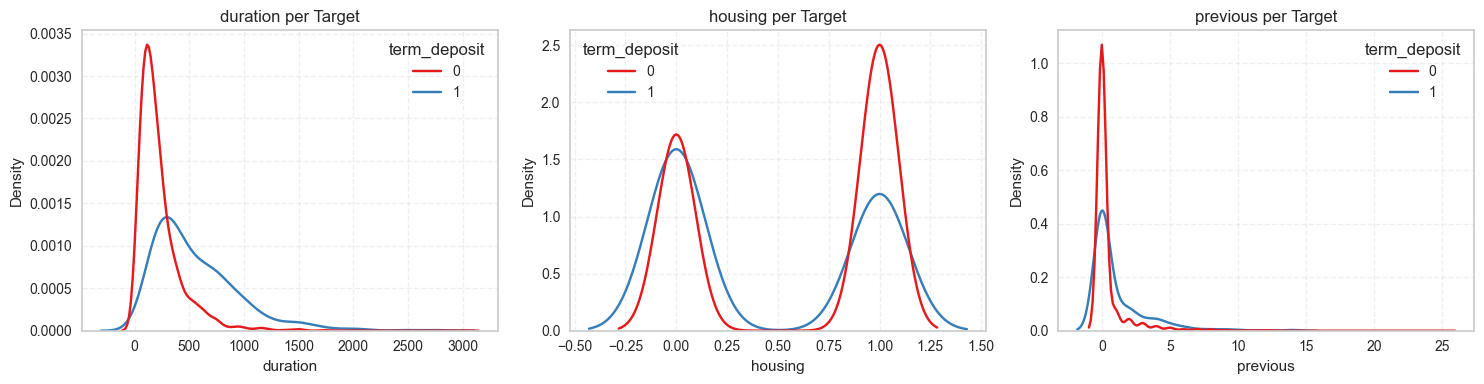

In [30]:
features = t_test_df['Feature'].values[:3]

fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 4))

if len(features) == 1:
    axes = [axes]

for ax, feature in zip(axes, features):
    sns.kdeplot(
        data=data_encoded,
        x=feature,
        hue='term_deposit',
        fill=False,
        palette='Set1',
        common_norm=False,
        ax=ax
    )
    ax.set_title(f'{feature} per Target')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

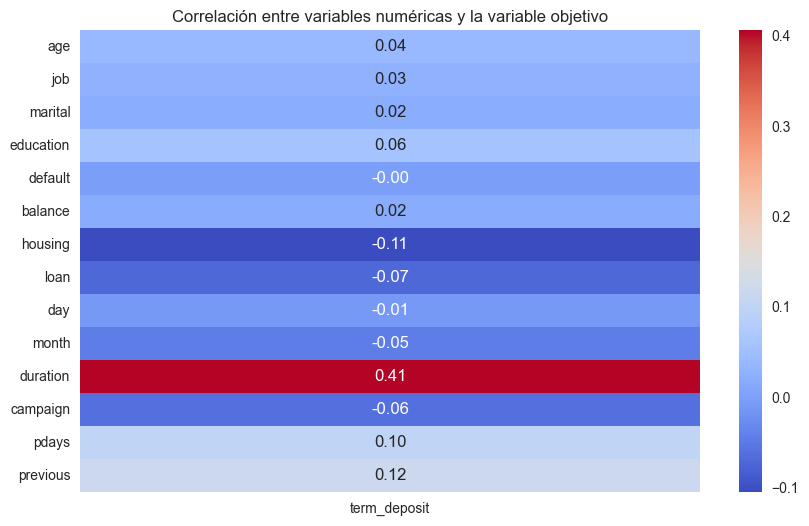

In [31]:
# Вычислите и визуализируйте корреляцию между числовыми фичами и целевой переменной с помощью тепловой карты.
correlation_with_target = data_encoded.corr()['term_deposit'].drop('term_deposit')

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_with_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    cbar=True,
    fmt=".2f"
)
plt.title('Correlación entre variables numéricas y la variable objetivo')
plt.show()

# 4) Подготовка данных для обучения

In [33]:
X=data_encoded.iloc[:,:-1]
y=data_encoded.iloc[:,-1]

In [34]:
# Примените случайную передискретизацию к матрице фичей X и целевой переменной y, чтобы устранить дисбаланс классов.
sm=RandomOverSampler()
X, y = sm.fit_resample(X, y)

In [26]:
# Нормализуем данные.
sc = MinMaxScaler()
X = sc.fit_transform(X)

In [27]:
# Разделим датасет на в следующих пропорциях train 70%, validation 15% and test 15%
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_valid
)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_valid shape: {X_valid.shape}, y_valid shape: {y_valid.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (5337, 14), y_train shape: (5337,)
X_valid shape: (1145, 14), y_valid shape: (1145,)
X_test shape: (1144, 14), y_test shape: (1144,)


# 3) Обучение модели

In [28]:
# Определяем словарь с нашими моделями
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}


Model: Logistic Regression


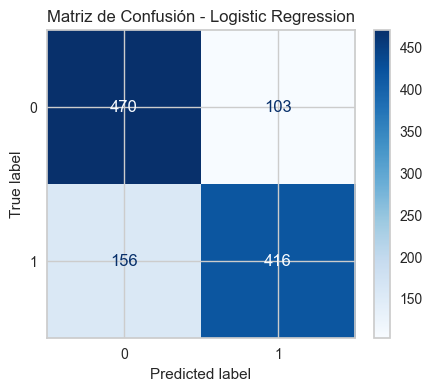

Classification Report:
              precision    recall  f1-score   support

     Clase 0       0.75      0.82      0.78       573
     Clase 1       0.80      0.73      0.76       572

    accuracy                           0.77      1145
   macro avg       0.78      0.77      0.77      1145
weighted avg       0.78      0.77      0.77      1145


Model: Random Forest


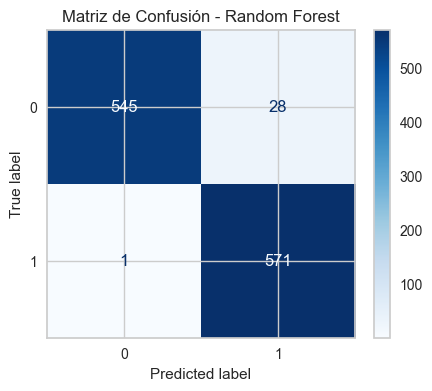

Classification Report:
              precision    recall  f1-score   support

     Clase 0       1.00      0.95      0.97       573
     Clase 1       0.95      1.00      0.98       572

    accuracy                           0.97      1145
   macro avg       0.98      0.97      0.97      1145
weighted avg       0.98      0.97      0.97      1145


Model: Decision Tree


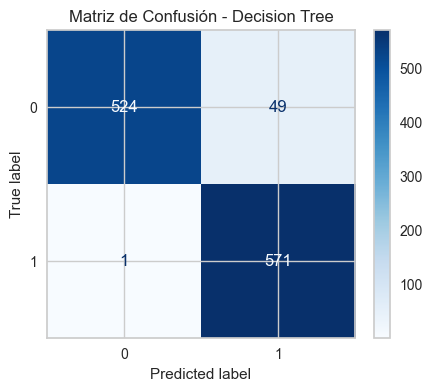

Classification Report:
              precision    recall  f1-score   support

     Clase 0       1.00      0.91      0.95       573
     Clase 1       0.92      1.00      0.96       572

    accuracy                           0.96      1145
   macro avg       0.96      0.96      0.96      1145
weighted avg       0.96      0.96      0.96      1145


Resumen General:
                 Model  Accuracy    Recall  F1 Score
0  Logistic Regression  0.773799  0.773759  0.773295
1        Random Forest  0.974672  0.974693  0.974659
2        Decision Tree  0.956332  0.956368  0.956258


In [29]:
# Обучаем и оцениваем каждую модель, отображает метрики.
results = {'Model': [], 'Accuracy': [], 'Recall': [], 'F1 Score': []}

for name, model in models.items():
    print(f'\nModel: {name}')
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    
    acc = accuracy_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred, average='macro') 
    f1 = f1_score(y_valid, y_pred, average='macro')

    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

    cm = confusion_matrix(y_valid, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    fig, ax = plt.subplots(figsize=(5,4))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f'Matriz de Confusión - {name}')
    plt.show()
    
    report = classification_report(y_valid, y_pred, target_names=['Clase 0', 'Clase 1'])
    print('Classification Report:')
    print(report)

results_df = pd.DataFrame(results)
print('\nResumen General:')
print(results_df)

Test Accuracy: 0.9755
Test Recall: 1.0000
Test F1 Score: 0.9761

Classification Report:
              precision    recall  f1-score   support

     Clase 0       1.00      0.95      0.97       572
     Clase 1       0.95      1.00      0.98       572

    accuracy                           0.98      1144
   macro avg       0.98      0.98      0.98      1144
weighted avg       0.98      0.98      0.98      1144



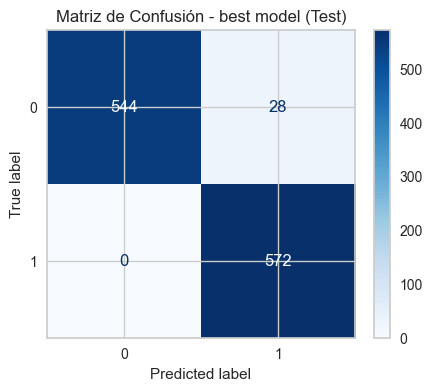

In [30]:
# Обучаем наилучшую модель на основе комбинированных данных обучения и отображаем показатели метрик.
best_model = models['Random Forest']
best_model.fit(pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_valid)]), pd.concat([y_train, y_valid]))

y_test_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Recall: {test_recall:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, target_names=['Clase 0', 'Clase 1']))

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - best model (Test)')
plt.show()